In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
####Data Preprocessing:
####Loading the dataset:
file = 'EastWestAirlines.xlsx'
pd.ExcelFile(file).sheet_names

['Description', 'data']

In [3]:
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

In [4]:
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [5]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [6]:
df.shape

(3999, 12)

In [7]:
df.size

47988

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [9]:
#####1.Handling the missing values, removing outliers, and scaling the features:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

ID#                  int64
Balance              int64
Qual_miles           int64
cc1_miles            int64
cc2_miles            int64
cc3_miles            int64
Bonus_miles          int64
Bonus_trans          int64
Flight_miles_12mo    int64
Flight_trans_12      int64
Days_since_enroll    int64
Award?               int64
dtype: object

In [12]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


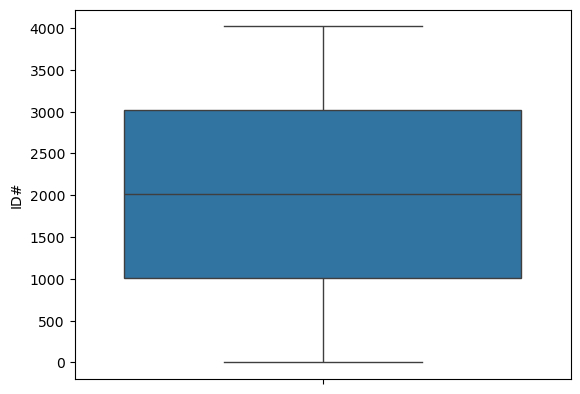

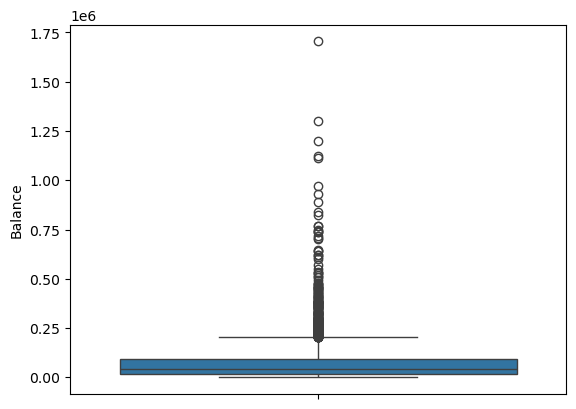

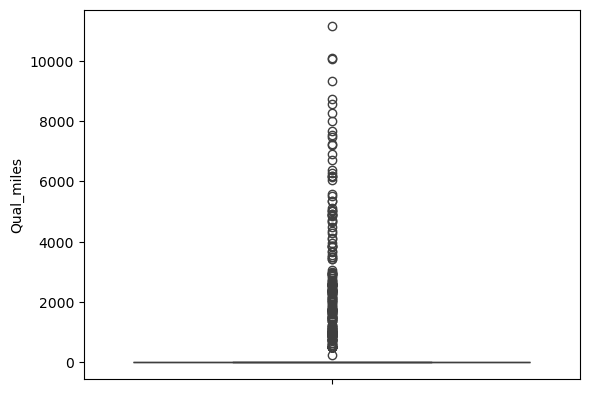

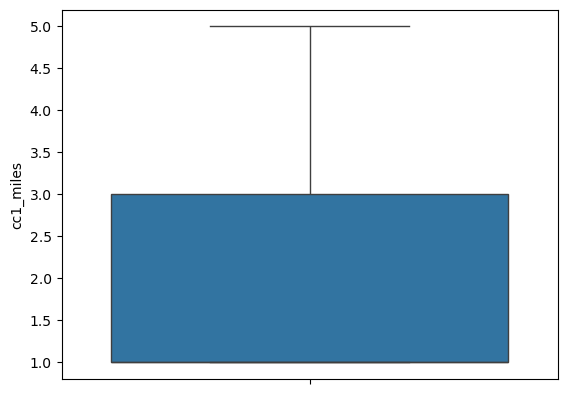

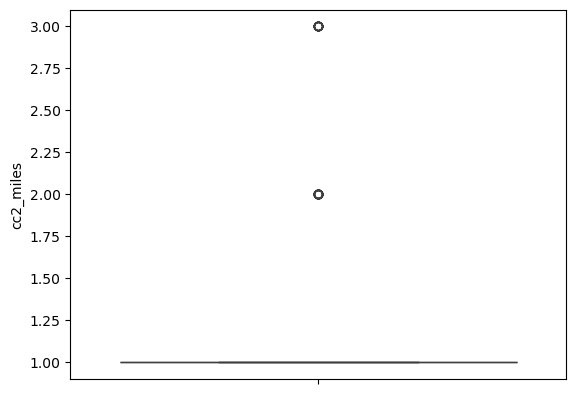

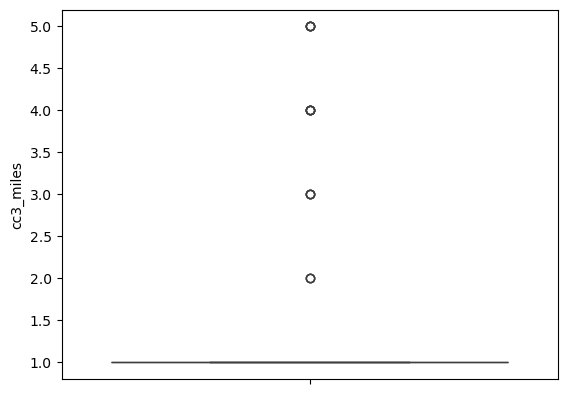

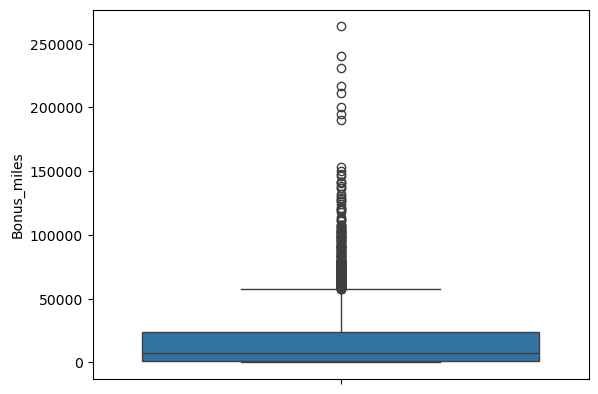

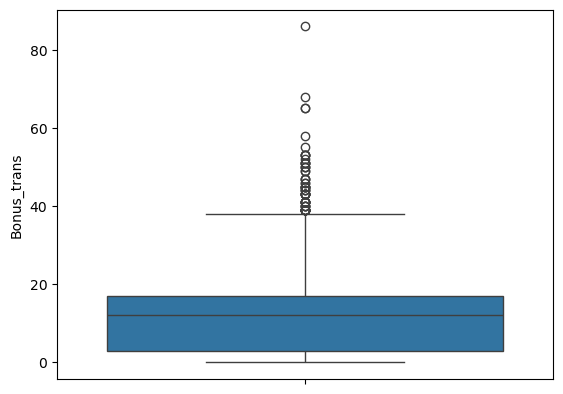

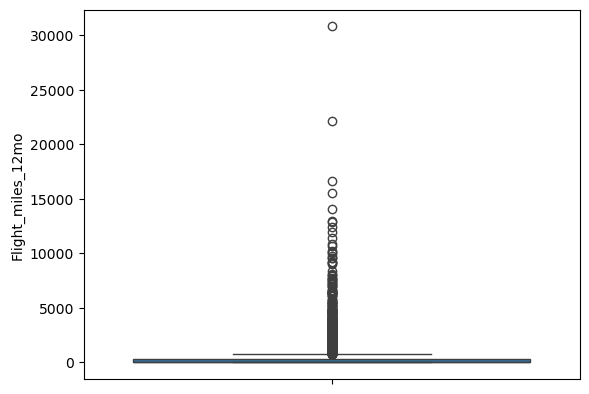

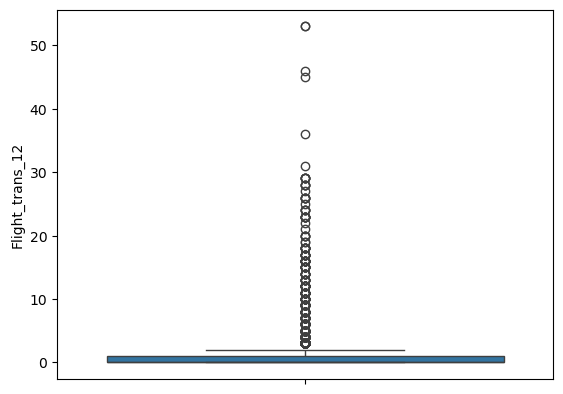

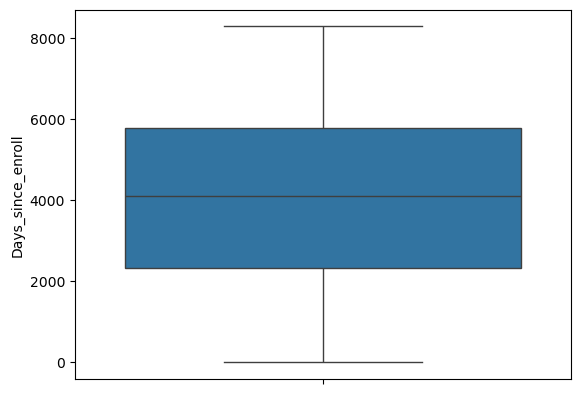

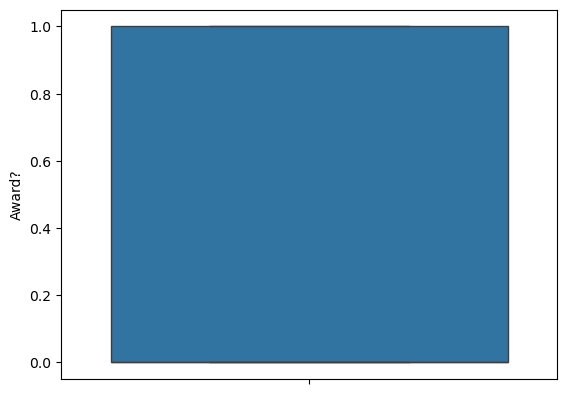

In [13]:
###Checking Outliers:
import seaborn as sns
import matplotlib.pyplot as plt
#Checking Boxplots
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [14]:
#Outlier Capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    df[i]=df[i].clip(lower,upper)

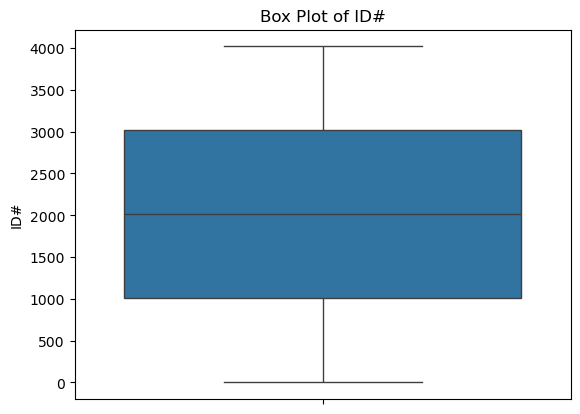

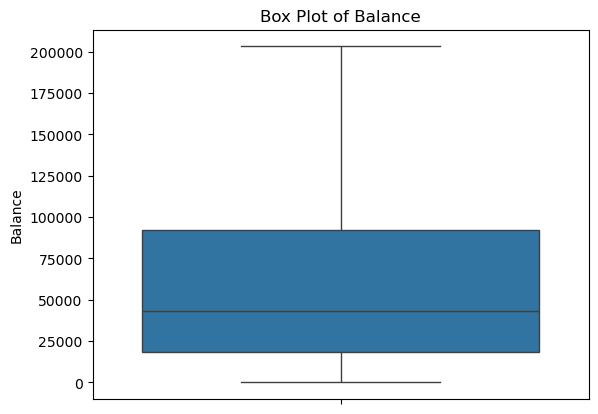

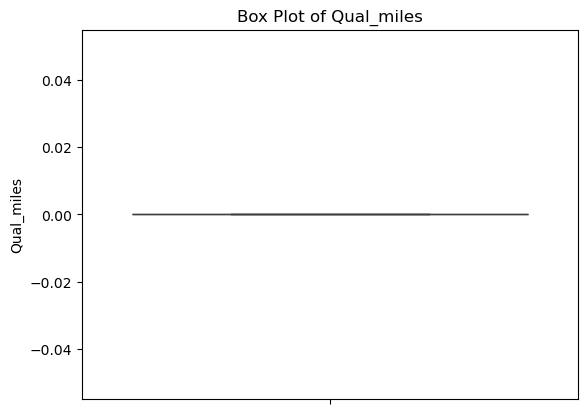

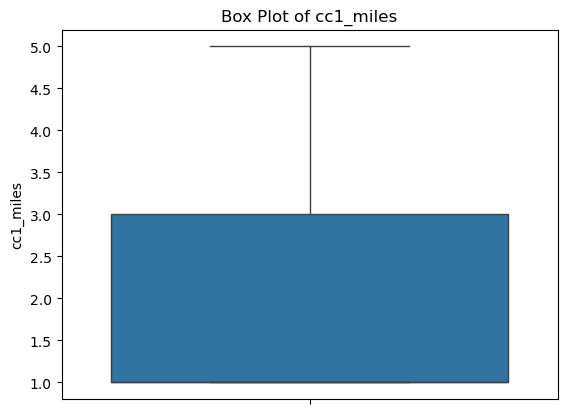

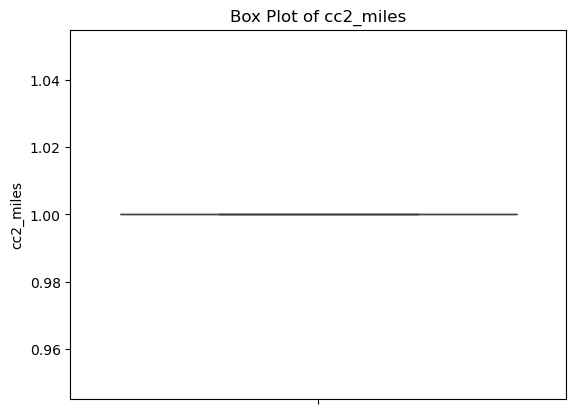

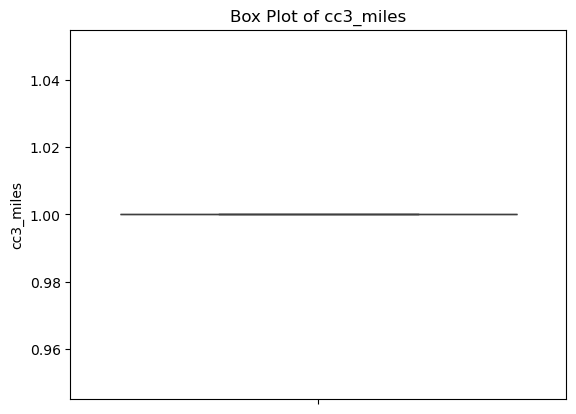

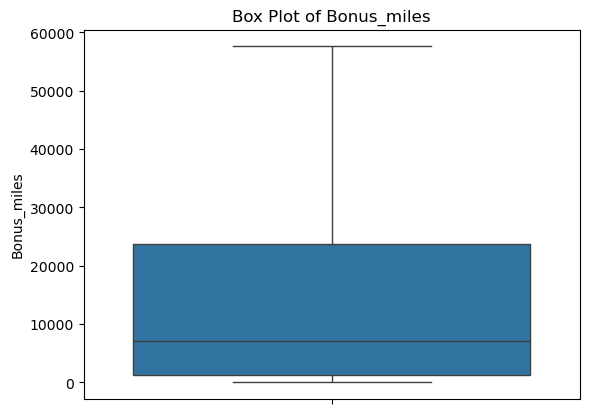

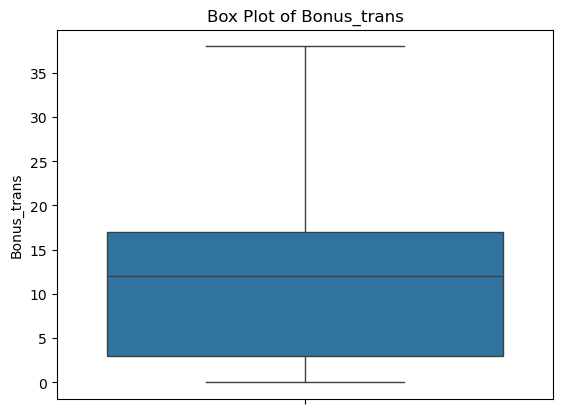

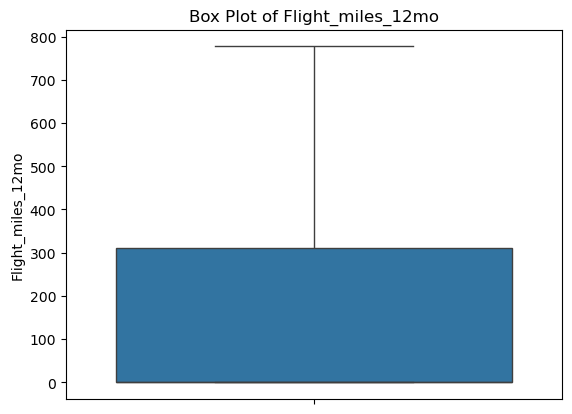

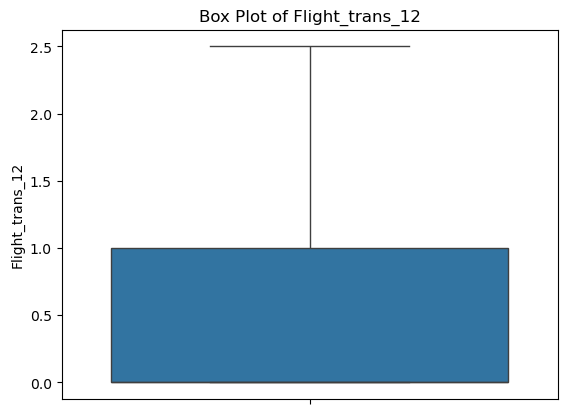

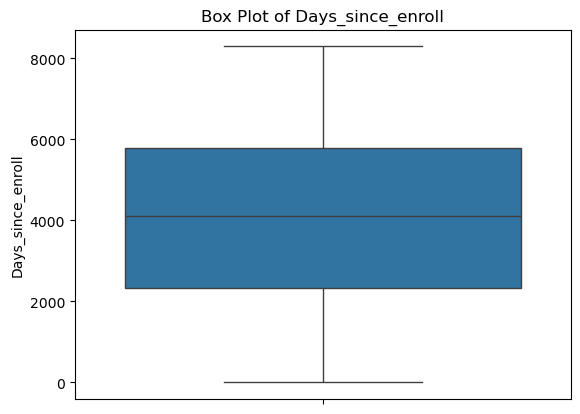

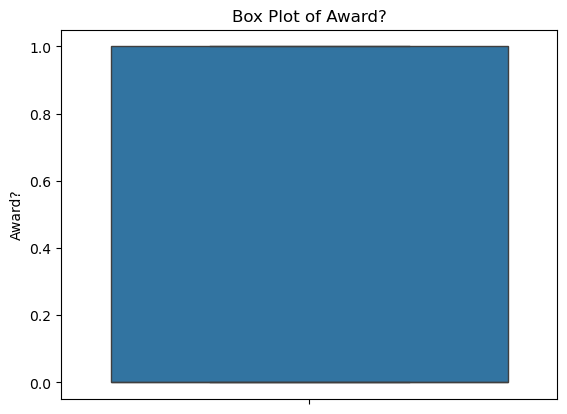

In [15]:
#Checking outliers after capping
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df) 
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

In [17]:
scaled_df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.735125,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919
1,-1.734263,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919
2,-1.733402,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919
3,-1.732540,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919
4,-1.731679,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918


## Explanation:
        “Feature scaling was performed using StandardScaler so that all variables are on the same scale, which improves the performance of clustering algorithms such as K-Means and DBSCAN.”

In [18]:
#####2.Exploratory Data Analysis (EDA):
####Display basic statistics:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3999.000000,3999.0,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,63768.635784,0.0,2.059515,1.0,1.0,15410.730683,11.470618,178.055639,0.591523,4118.55939,0.370343
std,1160.764358,58673.700736,0.0,1.376919,0.0,0.0,18074.733482,9.115104,294.678028,0.944826,2065.13454,0.482957
min,1.000000,0.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,18527.500000,0.0,1.000000,1.0,1.0,1250.000000,3.000000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,43097.000000,0.0,1.000000,1.0,1.0,7171.000000,12.000000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,92404.000000,0.0,3.000000,1.0,1.0,23800.500000,17.000000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,203218.750000,0.0,5.000000,1.0,1.0,57626.250000,38.000000,777.500000,2.500000,8296.00000,1.000000


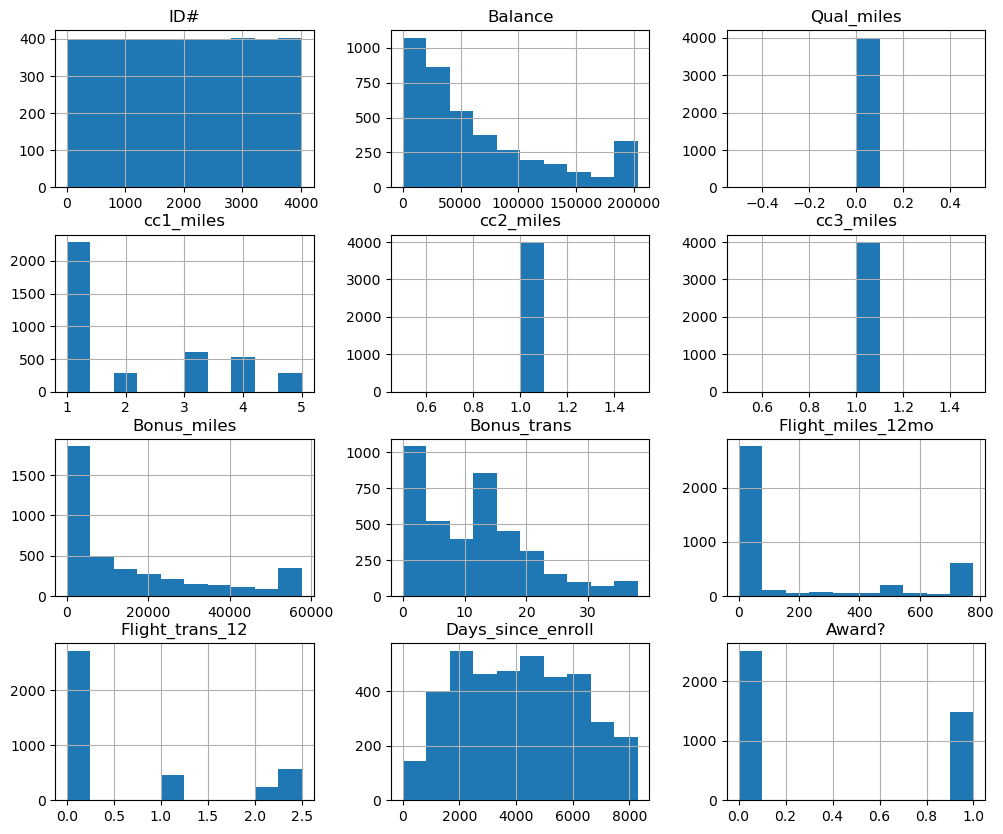

In [19]:
####Check data distribution using histograms:
df.hist(figsize=(12,10))
plt.show()

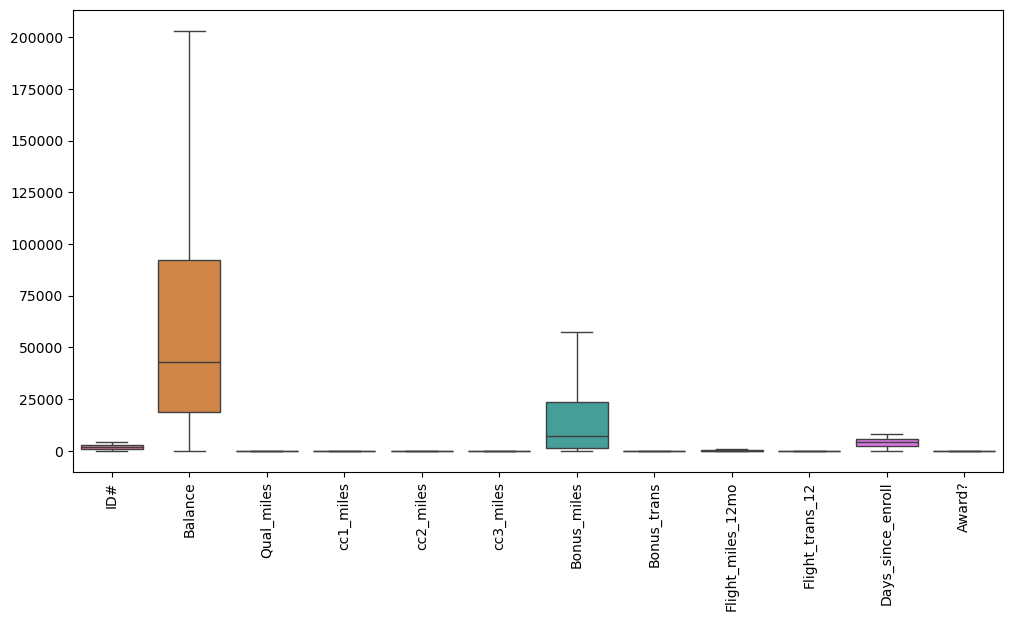

In [20]:
###Visualize outliers and spread using boxplots:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

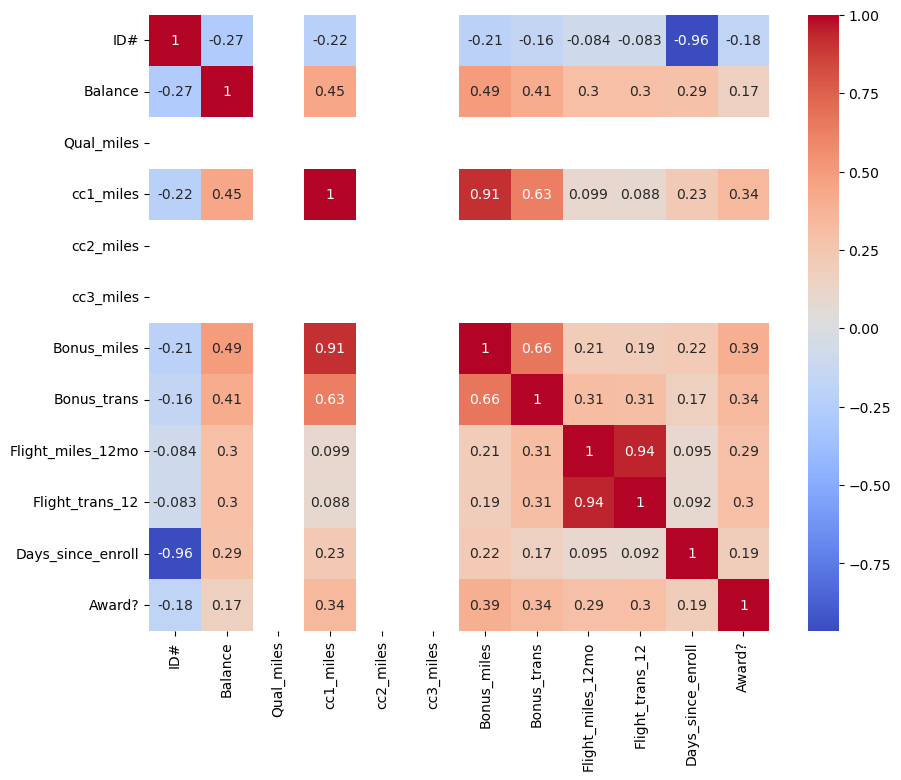

In [21]:
####Correlation heatmap:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

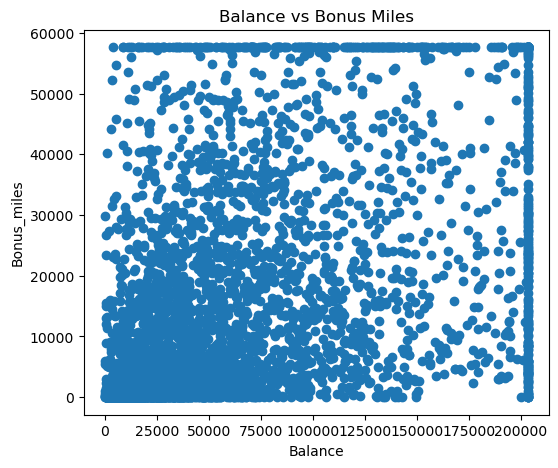

In [22]:
#####Scatter plot for possible clusters:
plt.figure(figsize=(6,5))
plt.scatter(df['Balance'], df['Bonus_miles'])
plt.xlabel('Balance')
plt.ylabel('Bonus_miles')
plt.title('Balance vs Bonus Miles')
plt.show()

## Exploratory Data Analysis (EDA):
            EDA was performed to understand the distribution and relationships of the airline customer data. Descriptive statistics were generated using describe(). Histograms were plotted to examine feature distributions, and boxplots were used to observe data spread and check for remaining outliers. A correlation heatmap was created to identify relationships among variables, while scatter plots were used to visually inspect potential customer clusters. The analysis indicated that some variables are correlated and that the dataset contains groups of customers with similar balance and bonus-mile patterns, suggesting the presence of potential clusters suitable for K-Means and DBSCAN clustering.

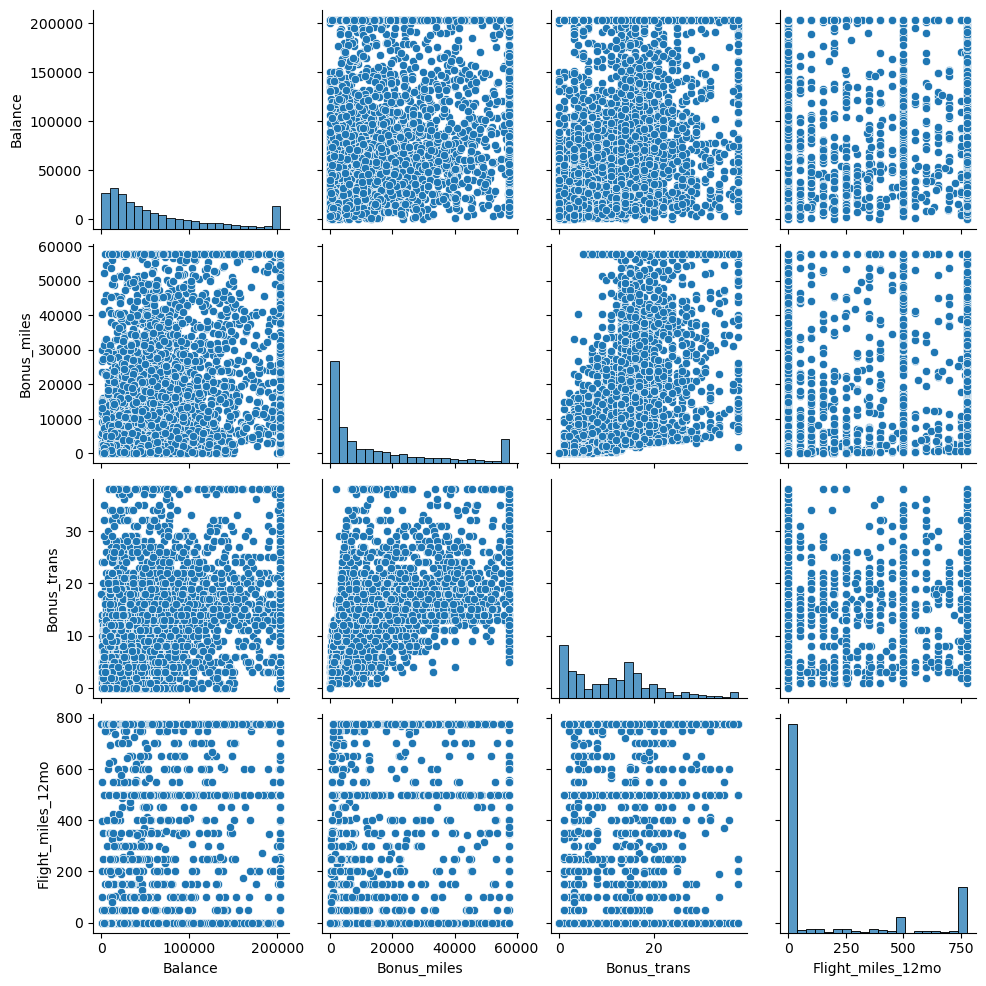

In [23]:
####3.Additional visualizations to understand the hidden patterns in the dataset:
####Pair Plot:
sns.pairplot(df[['Balance','Bonus_miles','Bonus_trans','Flight_miles_12mo']])
plt.show()

## Explanation:
        “In the EDA section, histograms, scatter plots, correlation heatmaps, and box plots were already used. To further explore hidden patterns, a pair plot was created to examine relationships among important variables and identify potential customer groups.”

In [24]:
#####Implementing Clustering Algorithms:
####K-Means Clustering:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_df)
kmeans_labels[:10]

array([1, 1, 1, 1, 3, 1, 2, 0, 3, 3], dtype=int32)

In [25]:
###DBSCAN Clustering:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df)
dbscan_labels[:10]

array([ 0,  0,  0,  0,  1,  0,  0,  1, -1,  1])

## Explanation:
            “K-Means and DBSCAN clustering algorithms were implemented using Python and the scikit-learn library. K-Means was used to divide the data into a fixed number of clusters, while DBSCAN was used to identify dense groups and noise points. Both algorithms were applied to the preprocessed dataset to discover clusters within the airline customer data.”

In [26]:
#####Applying Clustering Algorithms:
##K-Means Clustering:
##Apply K-Means:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_df)

scaled_df['KMeans_Cluster'] = kmeans_labels

In [27]:
###DBSCAN Clustering:
##Apply DBSCAN:
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df.drop('KMeans_Cluster', axis=1))

scaled_df['DBSCAN_Cluster'] = dbscan_labels

## Explanation:
         “K-Means and DBSCAN were applied to the pre-processed (scaled) dataset to identify groups of similar customers. K-Means assigned each customer to a cluster, while DBSCAN identified dense clusters and detected noise or outlier points.”

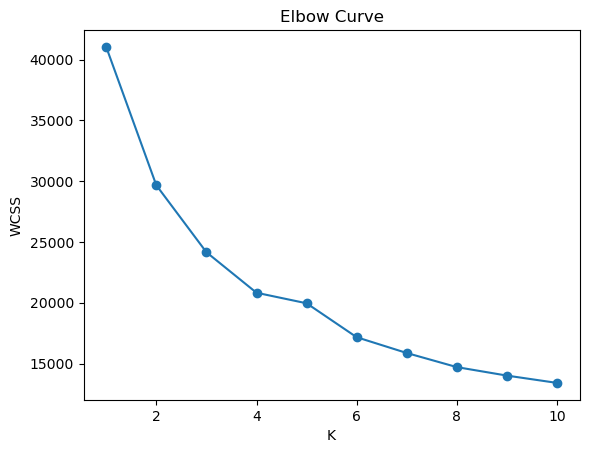

In [28]:
##K-Means – Elbow Method:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_df)
    wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Curve')
plt.show()

In [29]:
##DBSCAN – Different Parameter Settings:
from sklearn.cluster import DBSCAN
for eps in [0.8, 1.0, 1.2]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(scaled_df)
    print('eps =', eps, 'Clusters =', len(set(labels)))

eps = 0.8 Clusters = 36
eps = 1.0 Clusters = 29
eps = 1.2 Clusters = 14


In [30]:
###Evaluate Clustering Results:
from sklearn.metrics import silhouette_score
kmeans_labels = KMeans(n_clusters=4, random_state=42).fit_predict(scaled_df)
kmeans_score = silhouette_score(scaled_df, kmeans_labels)
print('K-Means Silhouette Score:', kmeans_score)
dbscan_labels = DBSCAN(eps=1.2, min_samples=5).fit_predict(scaled_df)
dbscan_score = silhouette_score(scaled_df, dbscan_labels)
print('DBSCAN Silhouette Score:', dbscan_score)

K-Means Silhouette Score: 0.24341991782961045
DBSCAN Silhouette Score: 0.07188337430167922


## Explanation:
        “K-Means was evaluated using the Elbow Method for different K values, and DBSCAN was tested with different epsilon values. Silhouette scores were calculated to compare clustering quality, and the parameter setting with better cluster separation was selected.”

In [31]:
###Cluster Analysis and Interpretation:
##umber of records in each K-Means cluster
print(scaled_df['KMeans_Cluster'].value_counts())
# Number of records in each DBSCAN cluster
print(scaled_df['DBSCAN_Cluster'].value_counts())

KMeans_Cluster
1    1916
2    1063
0     630
3     390
Name: count, dtype: int64
DBSCAN_Cluster
 0    2361
 1    1336
-1     249
 4      15
 3      11
 2      10
 5       6
 7       6
 6       5
Name: count, dtype: int64


In [32]:
##K-Means Cluster Means:
df.groupby(kmeans_labels).mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,2064.812808,77239.237274,0.0,1.246305,1.0,1.0,8053.272989,10.707718,651.673235,2.119048,4072.433498,0.520525
1,3099.877703,33416.883855,0.0,1.370619,1.0,1.0,5763.340231,7.340790,20.444444,0.088740,2192.786726,0.160328
2,1068.634862,50633.025459,0.0,1.603670,1.0,1.0,7492.852294,8.731193,13.955963,0.069725,5763.762385,0.253211
3,1541.234619,112586.068822,0.0,4.057351,1.0,1.0,42572.701251,20.843587,284.199687,0.917623,4970.781022,0.701773


## Cluster Analysis and Interpretation:
   ## K-Means: 
           K-Means formed customer groups based on similar balance and bonus-mile values. One cluster contained low-value customers, another contained moderate customers, and another contained high-value frequent travelers.

   ## DBSCAN: 
           DBSCAN identified dense customer groups and detected some records as noise (-1), which represent outlier customers.
  
   ## Insight: 
           Both algorithms showed that customers have different travel behaviors, such as low usage, moderate usage, and high usage of airline services. 

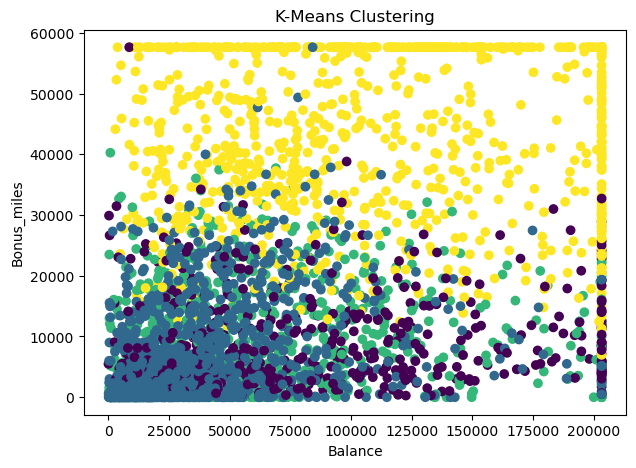

In [33]:
###Visualization:
#####K-Means Cluster Visualization:
plt.figure(figsize=(7,5))
plt.scatter(df['Balance'], df['Bonus_miles'],
            c=kmeans_labels, cmap='viridis')
plt.xlabel('Balance')
plt.ylabel('Bonus_miles')
plt.title('K-Means Clustering')
plt.show()

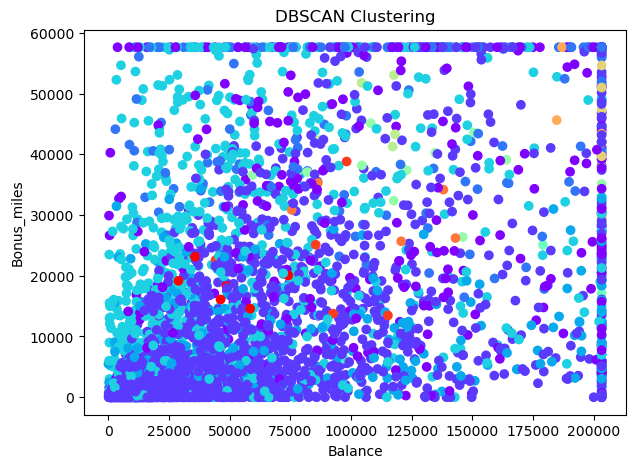

In [34]:
###DBSCAN Cluster Visualization:
plt.figure(figsize=(7,5))
plt.scatter(df['Balance'], df['Bonus_miles'],
            c=dbscan_labels, cmap='rainbow')
plt.xlabel('Balance')
plt.ylabel('Bonus_miles')
plt.title('DBSCAN Clustering')
plt.show()

## Explanation:
        “The clustering results were visualized using scatter plots of Balance vs Bonus_miles. Different colors were used to represent different clusters, which helped visualize the separation of customer groups and identify cluster boundaries and outlier points.”

## Evaluation and Performance Metrics:
    “The clustering quality was evaluated using the Silhouette Score for both K-Means and DBSCAN. Higher silhouette values indicate better cluster separation and compactness. The obtained scores were compared to identify the algorithm that produced better clustering results.”